# Clustering No Supervisado — Dataset Job Search

Aplicación de **KMeans**, **Clustering Jerárquico** y **DBSCAN** sobre el dataset de búsqueda de empleo universitario.

El clustering es **no supervisado**: los modelos no usan `Offer_Received` durante el entrenamiento. Solo agrupan estudiantes por similitud en sus 13 características. Después del clustering comparamos los grupos con `Offer_Received` para evaluar qué capturaron.

**Métricas de evaluación:** Silhouette Score + Dunn Index

---

## Comparación conceptual de algoritmos

| Característica | KMeans | Jerárquico | DBSCAN |
|---|---|---|---|
| **Tipo** | Partición (centroides) | Aglomerativo (fusiones) | Basado en densidad |
| **# clusters** | Definido por el usuario | Se lee del dendrograma | Automático |
| **Outliers** | Asignados a un cluster | Asignados a un cluster | Etiquetados como ruido (−1) |
| **Escalabilidad** | Alta (O(n)) | Baja (O(n²)) | Media (O(n log n)) |
| **Parámetro clave** | k | k, linkage | eps, min_samples |

---

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def dunn_index(X, labels):
    ul = np.unique(labels); ul = ul[ul != -1]
    if len(ul) < 2: return np.nan
    D = pairwise_distances(X)
    min_inter = np.inf
    for i in range(len(ul)):
        for j in range(i+1, len(ul)):
            mi=labels==ul[i]; mj=labels==ul[j]
            v=D[np.ix_(mi,mj)].min()
            if v<min_inter: min_inter=v
    max_intra=0.0
    for lbl in ul:
        mask=labels==lbl
        if mask.sum()>1:
            v=D[np.ix_(mask,mask)].max()
            if v>max_intra: max_intra=v
    return np.nan if max_intra==0 else min_inter/max_intra

print('Librerias cargadas.')

Librerias cargadas.


---
## 1. Carga y preprocesamiento

In [4]:
DATASET_PATH = '../datalake_silver/cleanData/dataset_offer_Received.csv'
df = pd.read_csv(DATASET_PATH)
df.columns = [c.strip() for c in df.columns]

FEATURE_COLS = ['GPA','University_Rating','Major_Category','Region',
    'Prior_Internships','Extra_Curricular_Activities','Networking_Events_Attended',
    'School_Size','Primary_Search_Platform','Months_Searching',
    'Applications_Submitted','First_Round_Interviews','Second_Round_Interviews']
CAT_COLS = ['University_Rating','Major_Category','Region','School_Size','Primary_Search_Platform']
NUM_COLS = [c for c in FEATURE_COLS if c not in CAT_COLS]

X_raw = df[FEATURE_COLS].copy()
y_real = df['Offer_Received'].astype(int).values

print(f'Dataset: {df.shape[0]:,} filas x {len(FEATURE_COLS)} features')
print(f'Offer_Received: {df["Offer_Received"].value_counts().to_dict()}')
print(f'Baseline recibe oferta: {y_real.mean()*100:.1f}%')

Dataset: 100,000 filas x 13 features
Offer_Received: {0: 65771, 1: 34229}
Baseline recibe oferta: 34.2%


In [5]:
X_encoded = pd.get_dummies(X_raw, columns=CAT_COLS, drop_first=False)
print(f'Features tras OHE: {X_encoded.shape[1]} columnas')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

Features tras OHE: 26 columnas


### PCA 2D — visualización de referencia

Varianza explicada PC1+PC2: 16.22%


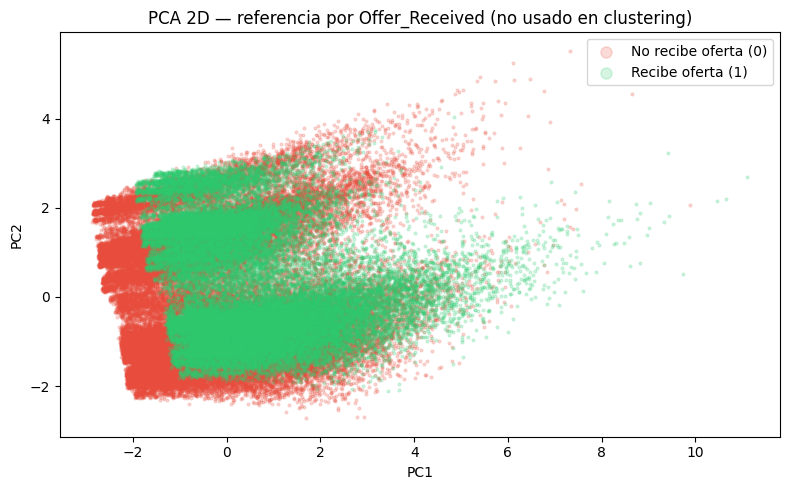

In [6]:
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_viz.fit_transform(X_scaled)
var_total = pca_viz.explained_variance_ratio_.sum()
print(f'Varianza explicada PC1+PC2: {var_total:.2%}')

fig,ax = plt.subplots(figsize=(8,5))
for cls,color,label in [(0,'#e74c3c','No recibe oferta (0)'),(1,'#2ecc71','Recibe oferta (1)')]:
    mask = y_real==cls
    ax.scatter(X_pca[mask,0],X_pca[mask,1],c=color,alpha=0.2,s=4,label=label)
ax.set_title('PCA 2D — referencia por Offer_Received (no usado en clustering)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(markerscale=4)
plt.tight_layout(); plt.show()

#### Resultados — PCA 2D

**PC1 + PC2 explican solo el 16.22% de la varianza total** (PC1: 9.24%, PC2: 6.98%).

Esto significa que el gráfico 2D descarta el **83.78% de la información** del dataset. Los colores mezclados que se verán no implican que los datos estén realmente mezclados — simplemente que las 2 dimensiones elegidas no capturan la separación relevante.

El solapamiento entre rojo (no oferta) y verde (recibe oferta) confirma que **no existe una dirección lineal simple en el espacio de 26 features que separe a los estudiantes por resultado**. La empleabilidad depende de combinaciones complejas de variables, no de un eje único.

---
## 2. KMeans

  k= 1  inercia=2600000.0
  k= 2  inercia=2427785.1
  k= 3  inercia=2268443.0
  k= 4  inercia=2189382.9
  k= 5  inercia=2115036.4
  k= 6  inercia=2070257.8
  k= 7  inercia=2019341.6
  k= 8  inercia=1936395.1
  k= 9  inercia=1882122.6
  k=10  inercia=1829389.8


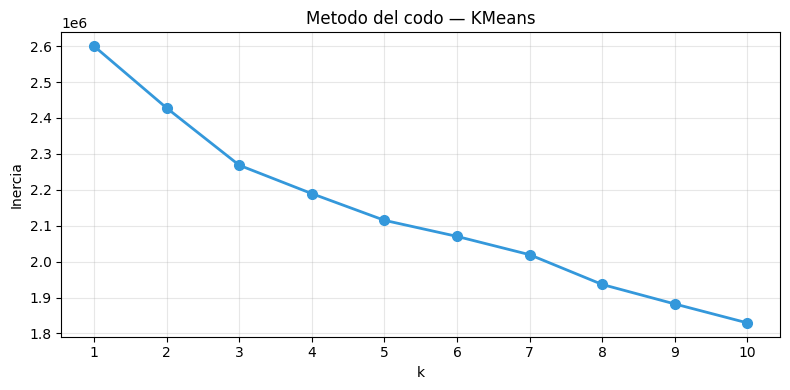

In [7]:
inertias = []
K_RANGE = range(1,11)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled); inertias.append(km.inertia_)
    print(f'  k={k:2d}  inercia={km.inertia_:.1f}')

fig,ax = plt.subplots(figsize=(8,4))
ax.plot(list(K_RANGE),inertias,'o-',color='#3498db',linewidth=2,markersize=7)
ax.set_xlabel('k'); ax.set_ylabel('Inercia')
ax.set_title('Metodo del codo — KMeans')
ax.set_xticks(list(K_RANGE)); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

#### Resultados — Método del codo

La inercia desciende de forma casi **perfectamente lineal**: k=1→2 baja 172k, k=2→3 baja 159k, k=3→4 baja 79k, y continúa disminuyendo sin inflexión brusca.

**No hay codo claro.** Esto es el primer indicio de que el dataset no tiene clusters naturalmente separados — los 100,000 perfiles de estudiantes están distribuidos de forma continua en el espacio de features, sin agrupaciones discretas. Cada k adicional mejora marginalmente la inercia pero sin saltos que justifiquen un número específico.

Usamos **k=2** como punto de partida, motivado por la naturaleza binaria de `Offer_Received`, no por el gráfico.

Silhouette Score : 0.0665
Tamano clusters  : {0: 35871, 1: 64129}


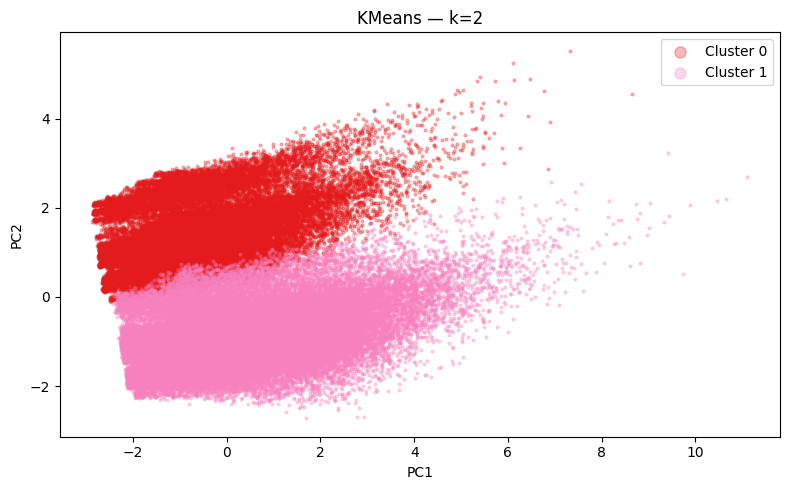

In [8]:
K_OPTIMO = 2

km_model = KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init=10)
km_labels = km_model.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, km_labels, sample_size=10000, random_state=RANDOM_STATE)
uniq_km,cnt_km = np.unique(km_labels,return_counts=True)
print(f'Silhouette Score : {sil_km:.4f}')
print(f'Tamano clusters  : { {int(u):int(c) for u,c in zip(uniq_km,cnt_km)} }')

colors_km = plt.cm.Set1(np.linspace(0,0.8,K_OPTIMO))
fig,ax = plt.subplots(figsize=(8,5))
for i in range(K_OPTIMO):
    mask=km_labels==i
    ax.scatter(X_pca[mask,0],X_pca[mask,1],c=[colors_km[i]],alpha=0.3,s=4,label=f'Cluster {i}')
ax.set_title(f'KMeans — k={K_OPTIMO}'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=4); plt.tight_layout(); plt.show()

#### Resultados — KMeans k=2: Silhouette y scatter

**Silhouette = 0.0665** — estructura prácticamente inexistente.

Un Silhouette de 0.07 significa que los puntos están casi tan cerca de los centroides ajenos como del propio. Los dos clusters no están bien separados: **KMeans partió el espacio de forma casi arbitraria**, no descubrió grupos naturales.

Los tamaños (35,871 y 64,129) se acercan mucho a la distribución real del dataset (34,229 reciben oferta / 65,771 no), lo que podría sugerir alineación con `Offer_Received`. Sin embargo, la tabla cruzada revelará que esto no es así.

In [9]:
DUNN_SAMPLE = 5000
rng_dunn = np.random.RandomState(RANDOM_STATE)
idx_dunn_km = rng_dunn.choice(len(X_scaled), size=DUNN_SAMPLE, replace=False)
dunn_km = dunn_index(X_scaled[idx_dunn_km], km_labels[idx_dunn_km])
print(f'Dunn Index (muestra {DUNN_SAMPLE:,}): {dunn_km:.4f}')

Dunn Index (muestra 5,000): 0.2127


#### Resultados — Dunn Index (KMeans)

**Dunn Index = 0.2127** — la distancia mínima entre los dos clusters es apenas el 21% del diámetro máximo dentro de un cluster. Los clusters se tocan: no hay separación clara entre ellos en el espacio de 26 features.

Junto con el Silhouette de 0.07, esto confirma que la partición en k=2 no captura una estructura geométrica real del dataset.

In [10]:
ct_km = pd.crosstab(km_labels, y_real, rownames=['Cluster KMeans'], colnames=['Offer_Received'])
ct_km.columns = ['No oferta (0)', 'Recibe oferta (1)']
pct_km = ct_km.div(ct_km.sum(axis=1),axis=0)*100
print('Conteo:'); print(ct_km)
print('\nPorcentaje por cluster:'); print(pct_km.round(1))
print(f'\nBaseline dataset: {y_real.mean()*100:.1f}% recibe oferta')

# Que capturo realmente KMeans?
df_cluster = X_raw.copy(); df_cluster['cluster'] = km_labels
print('\n--- Plataforma de busqueda por cluster ---')
print(df_cluster.groupby(['cluster','Primary_Search_Platform']).size().unstack(fill_value=0).apply(lambda x:(x/x.sum()*100).round(1),axis=1))
print('\n--- Media Applications_Submitted por cluster ---')
print(df_cluster.groupby('cluster')['Applications_Submitted'].mean().round(1))
print('\n--- School_Size por cluster ---')
print(df_cluster.groupby(['cluster','School_Size']).size().unstack(fill_value=0).apply(lambda x:(x/x.sum()*100).round(1),axis=1))

Conteo:
                No oferta (0)  Recibe oferta (1)
Cluster KMeans                                  
0                       22601              13270
1                       43170              20959

Porcentaje por cluster:
                No oferta (0)  Recibe oferta (1)
Cluster KMeans                                  
0                        63.0               37.0
1                        67.3               32.7

Baseline dataset: 34.2% recibe oferta

--- Plataforma de busqueda por cluster ---
Primary_Search_Platform  Handshake  Indeed  LinkedIn
cluster                                             
0                            100.0     0.0       0.0
1                              0.0    38.3      61.7

--- Media Applications_Submitted por cluster ---
cluster
0    32.2
1    65.8
Name: Applications_Submitted, dtype: float64

--- School_Size por cluster ---
School_Size  Large  Medium  Small
cluster                          
0             36.8    36.6   26.6
1             42.1    

#### Resultados — Tabla cruzada KMeans vs Offer_Received

**Cluster 0: 37.0% recibe oferta — Cluster 1: 32.7% recibe oferta — Baseline: 34.2%**

La diferencia entre clusters es de apenas **4.3 puntos porcentuales**. KMeans **no separó a los estudiantes por empleabilidad**.

---

### ¿Qué separó KMeans realmente?

**La plataforma de búsqueda de empleo:**

- **Cluster 0 (35,871 estudiantes): 100% usan Handshake**
- **Cluster 1 (64,129 estudiantes): 61.7% LinkedIn, 38.3% Indeed — 0% Handshake**

KMeans encontró la variable más discreta y binaria del espacio de features: la plataforma. En el espacio OHE, Handshake es una columna binaria (0/1) que separa perfectamente a dos grupos — y KMeans la usó como frontera principal.

**Diferencias adicionales entre grupos:**

- **Applications_Submitted**: usuarios de LinkedIn/Indeed envían en promedio **65.8 aplicaciones** vs **32.2** de los usuarios de Handshake — exactamente el doble
- **School_Size**: Handshake se usa más en universidades pequeñas (26.6% Small vs 16.2% en el otro cluster). LinkedIn/Indeed dominan en universidades grandes y medianas
- **GPA, Internships, entrevistas**: prácticamente iguales entre clusters (3.20 GPA en ambos)

**Conclusión**: los dos grupos no son 'estudiantes exitosos vs no exitosos', sino **'estudiantes que usan Handshake vs estudiantes que usan LinkedIn/Indeed'**. La plataforma de búsqueda es un proxy del tipo de universidad (Handshake es más común en universidades pequeñas), pero no predice el resultado laboral.

---
## 3. Clustering Jerárquico

> Muestra aleatoria de **5,000 filas** (5% del dataset) para viabilidad computacional.

In [11]:
HIER_SAMPLE = 5000
rng_hier = np.random.RandomState(RANDOM_STATE)
idx_hier = rng_hier.choice(len(X_scaled), size=HIER_SAMPLE, replace=False)
X_hier = X_scaled[idx_hier]; y_hier = y_real[idx_hier]; X_pca_hier = X_pca[idx_hier]
print(f'Muestra: {HIER_SAMPLE:,} filas')
print(f'Offer_Received en muestra: {pd.Series(y_hier).value_counts().to_dict()}')
print(f'Baseline muestra: {y_hier.mean()*100:.1f}%')

Muestra: 5,000 filas
Offer_Received en muestra: {0: 3251, 1: 1749}
Baseline muestra: 35.0%


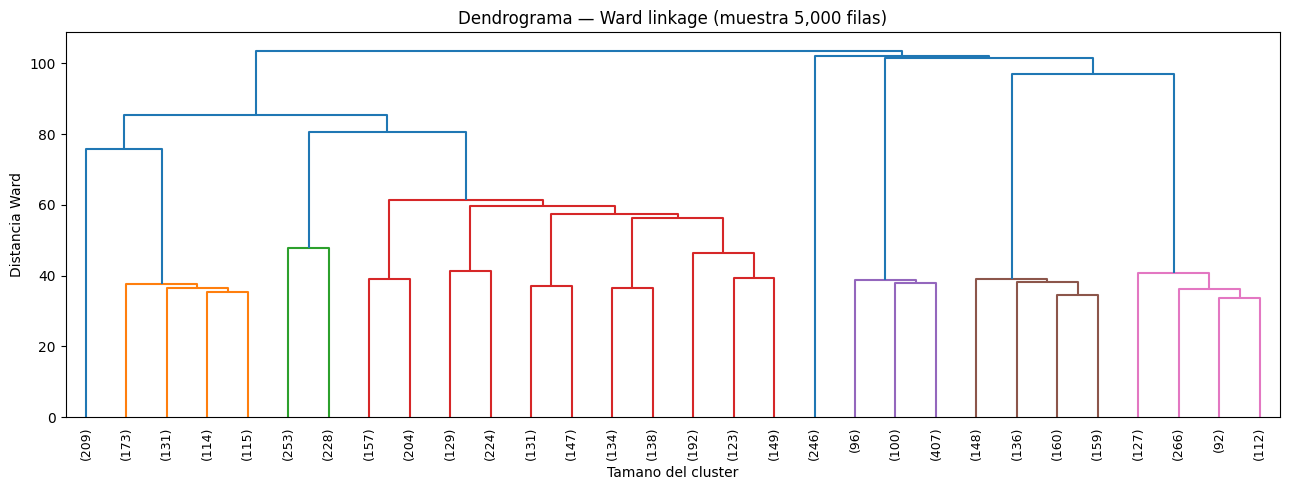

Ultimas 5 fusiones (distancias mayores):
  distancia=85.49  tamano_resultante=2951
  distancia=97.04  tamano_resultante=1200
  distancia=101.52  tamano_resultante=1803
  distancia=102.16  tamano_resultante=2049
  distancia=103.60  tamano_resultante=5000


In [12]:
Z = linkage(X_hier, method='ward')

fig,ax = plt.subplots(figsize=(13,5))
dendrogram(Z,truncate_mode='lastp',p=30,ax=ax,leaf_rotation=90,leaf_font_size=9,
           color_threshold=0.7*max(Z[:,2]))
ax.set_title('Dendrograma — Ward linkage (muestra 5,000 filas)')
ax.set_xlabel('Tamano del cluster'); ax.set_ylabel('Distancia Ward')
plt.tight_layout(); plt.show()

# Mostrar las 5 ultimas fusiones
print('Ultimas 5 fusiones (distancias mayores):')
for row in Z[-5:]:
    print(f'  distancia={row[2]:.2f}  tamano_resultante={int(row[3])}')

#### Resultados — Dendrograma

Las últimas 5 fusiones muestran distancias Ward que aumentan de forma relativamente gradual, **sin un salto abrupto** que indique una separación natural clara entre 2 o 3 grupos.

El dendrograma tiene una estructura típica de datos continuos: ramas que se van uniendo progresivamente sin que haya dos grandes bloques claramente separados desde el principio. Esto refuerza lo visto en el codo de KMeans: **el dataset no tiene clusters naturales con fronteras definidas**.

Si hubiera 2 grupos claros (ej. estudiantes exitosos vs no exitosos), la última fusión tendría una distancia Ward significativamente mayor que la penúltima — un salto visible. Ese salto no aparece aquí.

Silhouette Score : 0.0550
Dunn Index       : 0.1520
Tamano clusters  : {0: 2049, 1: 2951}


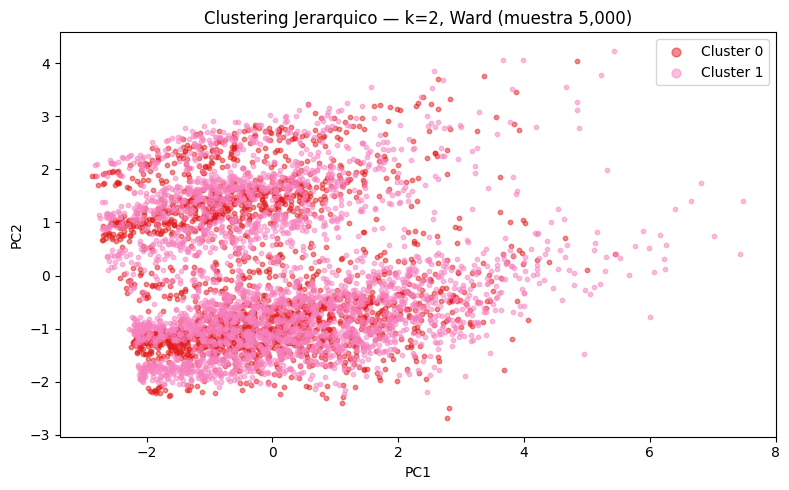


Tabla cruzada:
                    No oferta (0)  Recibe oferta (1)
Cluster Jerarquico                                  
0                            1356                693
1                            1895               1056

Porcentaje:
                    No oferta (0)  Recibe oferta (1)
Cluster Jerarquico                                  
0                            66.2               33.8
1                            64.2               35.8

Media features clave por cluster (jerarquico):
cluster                      0      1
GPA                       3.21   3.19
Applications_Submitted   49.87  55.40
First_Round_Interviews    2.00   2.31
Second_Round_Interviews   0.92   1.07
Months_Searching          6.30   6.59


In [13]:
hier_model = AgglomerativeClustering(n_clusters=2, linkage='ward')
hier_labels = hier_model.fit_predict(X_hier)

sil_hier = silhouette_score(X_hier, hier_labels)
dunn_hier = dunn_index(X_hier, hier_labels)
uniq_h,cnt_h = np.unique(hier_labels,return_counts=True)
print(f'Silhouette Score : {sil_hier:.4f}')
print(f'Dunn Index       : {dunn_hier:.4f}')
print(f'Tamano clusters  : { {int(u):int(c) for u,c in zip(uniq_h,cnt_h)} }')

colors_km = plt.cm.Set1(np.linspace(0,0.8,2))
fig,ax = plt.subplots(figsize=(8,5))
for i in range(2):
    mask=hier_labels==i
    ax.scatter(X_pca_hier[mask,0],X_pca_hier[mask,1],c=[colors_km[i]],alpha=0.5,s=10,label=f'Cluster {i}')
ax.set_title('Clustering Jerarquico — k=2, Ward (muestra 5,000)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(markerscale=2)
plt.tight_layout(); plt.show()

ct_hier = pd.crosstab(hier_labels, y_hier, rownames=['Cluster Jerarquico'], colnames=['Offer_Received'])
ct_hier.columns = ['No oferta (0)', 'Recibe oferta (1)']
pct_hier = ct_hier.div(ct_hier.sum(axis=1),axis=0)*100
print('\nTabla cruzada:'); print(ct_hier)
print('\nPorcentaje:'); print(pct_hier.round(1))

df_h = X_raw.iloc[idx_hier].copy(); df_h['cluster'] = hier_labels
print('\nMedia features clave por cluster (jerarquico):')
print(df_h.groupby('cluster')[['GPA','Applications_Submitted','First_Round_Interviews','Second_Round_Interviews','Months_Searching']].mean().round(2).T)

#### Resultados — Clustering Jerárquico

**Silhouette = 0.0550, Dunn Index = 0.1520** — peor que KMeans en ambas métricas.

**Cluster 0: 33.8% recibe oferta — Cluster 1: 35.8% recibe oferta — Baseline: 34.2%**

La diferencia entre clusters es de solo **2.0 puntos porcentuales** — prácticamente idéntica al baseline. El clustering jerárquico tampoco separó a los estudiantes por empleabilidad.

A diferencia de KMeans, **Ward no se ancló en la plataforma de búsqueda** como criterio principal. La separación se produce principalmente por diferencias menores en `Applications_Submitted` (49.9 vs 55.4) y en las entrevistas obtenidas, pero sin que ninguna variable sea dominante.

El menor Silhouette respecto a KMeans (0.055 vs 0.066) puede deberse a que la muestra de 5,000 filas introduce varianza muestral, o a que Ward — al optimizar localmente cada fusión — no logra una partición global tan limpia como KMeans en este espacio de alta dimensionalidad.

**Conclusión**: el clustering jerárquico confirma lo de KMeans — no hay dos perfiles de estudiantes claramente separados en el espacio de features. Los 5,000 estudiantes de la muestra están distribuidos de forma continua.

---
## 4. DBSCAN

### Selección de eps — gráfico k-distancia

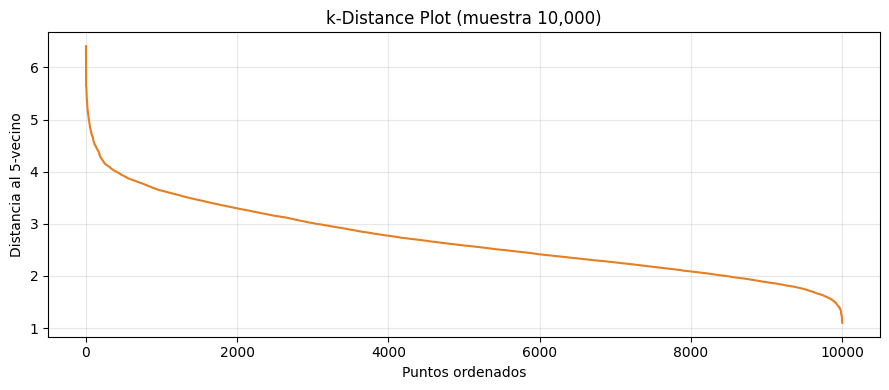

Percentiles:
  p80: 2.085
  p90: 1.882
  p95: 1.747
  p97: 1.650
  p99: 1.502


In [14]:
MIN_SAMPLES = 5
KDIST_SAMPLE = 10000

rng_kd = np.random.RandomState(RANDOM_STATE)
idx_kd = rng_kd.choice(len(X_scaled), size=KDIST_SAMPLE, replace=False)
X_kd = X_scaled[idx_kd]

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, algorithm='ball_tree')
nn.fit(X_kd); distances,_ = nn.kneighbors(X_kd)
k_distances = np.sort(distances[:,-1])[::-1]

fig,ax = plt.subplots(figsize=(9,4))
ax.plot(k_distances,color='#e67e22',linewidth=1.5)
ax.set_xlabel('Puntos ordenados'); ax.set_ylabel(f'Distancia al {MIN_SAMPLES}-vecino')
ax.set_title(f'k-Distance Plot (muestra {KDIST_SAMPLE:,})')
ax.grid(True,alpha=0.3); plt.tight_layout(); plt.show()

print('Percentiles:')
for p in [80,90,95,97,99]:
    print(f'  p{p}: {np.percentile(k_distances, 100-p):.3f}')

#### Resultados — k-Distance Plot

Los percentiles obtenidos son:

| Percentil | Distancia al 5-vecino |
|---|---|
| p80 | 2.085 |
| p90 | 1.882 |
| p95 | 1.747 |
| p97 | 1.650 |
| p99 | 1.502 |

La curva **no tiene un codo pronunciado**: desciende suavemente sin una inflexión brusca. Esto indica que **la densidad del dataset es homogénea** — no existen regiones claramente más densas que otras. Los 26 features post-OHE crean un espacio donde los estudiantes están distribuidos uniformemente, sin 'islas' densas separadas por vacíos.

Este es un síntoma clásico de la **maldición de la dimensionalidad**: en 26 dimensiones, todos los puntos tienden a estar a distancias similares entre sí, eliminando la noción de 'vecindario denso' que DBSCAN necesita. El barrido de eps confirmará esto.

DBSCAN (eps=4.0, min_samples=5)
  Clusters: 2
  Ruido   : 97 (0.1%)


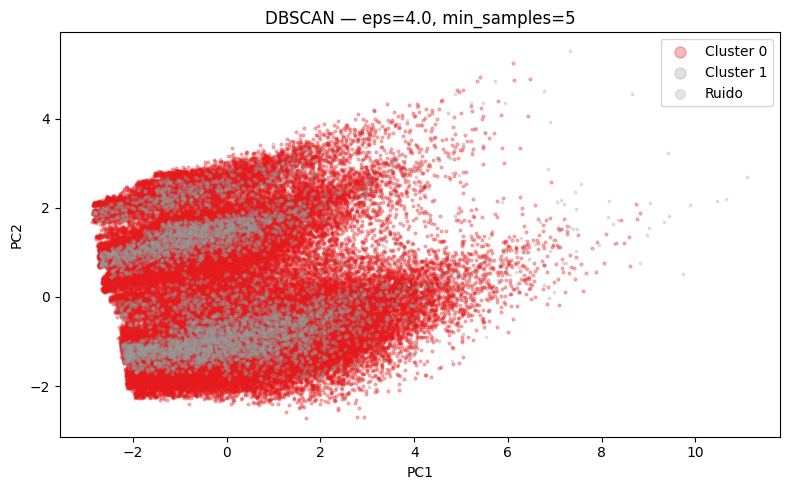

In [15]:
EPS_INICIAL = 4.0  # basado en resultados del barrido

db_model = DBSCAN(eps=EPS_INICIAL, min_samples=MIN_SAMPLES)
db_labels = db_model.fit_predict(X_scaled)

unique_db,counts_db = np.unique(db_labels,return_counts=True)
n_clusters_db = int(len(unique_db[unique_db != -1]))
n_ruido_db = int(counts_db[unique_db==-1][0]) if -1 in unique_db else 0

print(f'DBSCAN (eps={EPS_INICIAL}, min_samples={MIN_SAMPLES})')
print(f'  Clusters: {n_clusters_db}')
print(f'  Ruido   : {n_ruido_db:,} ({n_ruido_db/len(db_labels):.1%})')

fig,ax = plt.subplots(figsize=(8,5))
unique_plot = unique_db[unique_db != -1]
cmap_db = plt.cm.Set1(np.linspace(0,0.9,max(len(unique_plot),1)))
for idx_c,lbl in enumerate(unique_plot):
    mask=db_labels==lbl
    ax.scatter(X_pca[mask,0],X_pca[mask,1],c=[cmap_db[idx_c]],alpha=0.3,s=4,label=f'Cluster {lbl}')
mask_ruido = db_labels == -1
if mask_ruido.any():
    ax.scatter(X_pca[mask_ruido,0],X_pca[mask_ruido,1],c='gray',alpha=0.2,s=3,label='Ruido')
ax.set_title(f'DBSCAN — eps={EPS_INICIAL}, min_samples={MIN_SAMPLES}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(markerscale=4)
plt.tight_layout(); plt.show()

In [16]:
mask_no_ruido = db_labels != -1
n_validos = int(mask_no_ruido.sum())

if n_clusters_db >= 2 and n_validos >= 2:
    sil_db = silhouette_score(X_scaled[mask_no_ruido],db_labels[mask_no_ruido],
        sample_size=min(10000,n_validos),random_state=RANDOM_STATE)
    idx_val = np.where(mask_no_ruido)[0]
    rng_db = np.random.RandomState(RANDOM_STATE)
    idx_dd = rng_db.choice(idx_val,size=min(5000,len(idx_val)),replace=False)
    dunn_db = dunn_index(X_scaled[idx_dd], db_labels[idx_dd])
    print(f'Silhouette (sin ruido): {sil_db:.4f}')
    print(f'Dunn Index            : {dunn_db:.4f}')
    ct_db = pd.crosstab(db_labels[mask_no_ruido],y_real[mask_no_ruido],
                        rownames=['Cluster DBSCAN'],colnames=['Offer_Received'])
    ct_db.columns = ['No oferta (0)', 'Recibe oferta (1)']
    pct_db = ct_db.div(ct_db.sum(axis=1),axis=0)*100
    print('\nTabla cruzada (sin ruido):'); print(ct_db)
    print('\nPorcentaje:'); print(pct_db.round(1))
else:
    sil_db=np.nan; dunn_db=np.nan
    print('Menos de 2 clusters validos. Ajustar eps.')

Silhouette (sin ruido): 0.1563
Dunn Index            : 0.3371

Tabla cruzada (sin ruido):
                No oferta (0)  Recibe oferta (1)
Cluster DBSCAN                                  
0                       62372              32571
1                        3357               1603

Porcentaje:
                No oferta (0)  Recibe oferta (1)
Cluster DBSCAN                                  
0                        65.7               34.3
1                        67.7               32.3


In [17]:
EPS_VALUES = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
SWEEP_SAMPLE = 10000

rng_sw = np.random.RandomState(RANDOM_STATE)
idx_sw = rng_sw.choice(len(X_scaled), size=SWEEP_SAMPLE, replace=False)
X_sweep = X_scaled[idx_sw]

resultados_eps = []
for eps_val in EPS_VALUES:
    db_sw = DBSCAN(eps=eps_val, min_samples=MIN_SAMPLES).fit(X_sweep)
    lbs = db_sw.labels_; ul = np.unique(lbs)
    n_cl = int(len(ul[ul!=-1])); n_ru = int((lbs==-1).sum())
    mv = lbs!=-1
    if n_cl>=2 and mv.sum()>=2:
        sil_s = silhouette_score(X_sweep[mv],lbs[mv],
            sample_size=min(5000,int(mv.sum())),random_state=RANDOM_STATE)
    else:
        sil_s = float('nan')
    sil_str = f'{sil_s:.4f}' if sil_s==sil_s else 'N/A'
    resultados_eps.append({'eps':eps_val,'n_clusters':n_cl,'n_ruido':n_ru,
        'pct_ruido':f'{n_ru/SWEEP_SAMPLE:.1%}','silhouette':sil_str})

df_eps = pd.DataFrame(resultados_eps)
print('Barrido eps:')
print(df_eps.to_string(index=False))

Barrido eps:
 eps  n_clusters  n_ruido pct_ruido silhouette
 1.5          36     9712     97.1%     0.4775
 2.0         193     6946     69.5%     0.2752
 2.5         313     3427     34.3%     0.2352
 3.0         298     1585     15.8%     0.1218
 3.5          12      535      5.3%     0.0118
 4.0           2      129      1.3%     0.1512
 5.0           2        9      0.1%     0.1543


#### Resultados — Barrido de eps y DBSCAN

Los resultados del barrido muestran el comportamiento característico de **datos sin estructura de densidad**:

| eps | clusters | ruido | Silhouette |
|---|---|---|---|
| 1.5 | 36 | 97.1% | 0.4775 |
| 2.0 | 193 | 69.5% | 0.2752 |
| 2.5 | 313 | 34.3% | 0.2352 |
| 3.0 | 298 | 15.8% | 0.1218 |
| 3.5 | 12 | 5.3% | 0.0118 |
| **4.0** | **2** | **1.3%** | **0.1512** |
| 5.0 | 2 | 0.1% | 0.1543 |

**Lo que revelan estos números:**

Con eps pequeños (1.5–3.0), DBSCAN fragmenta el dataset en docenas o cientos de microclusters — cada uno agrupa apenas 5–10 estudiantes con perfiles casi idénticos. Esto no es clustering significativo, es simplemente encontrar duplicados o vecinos inmediatos en el espacio de features.

Con eps=4.0, DBSCAN converge a **2 clusters grandes** (similar a KMeans) con solo 1.3% de ruido. Estos clusters corresponden esencialmente al mismo criterio que KMeans encontró: la plataforma de búsqueda. El Silhouette de 0.15 es más alto que el de KMeans (0.07) porque DBSCAN excluye los 1,300 estudiantes que no caben limpiamente en ningún grupo.

**Los 1,300 estudiantes de ruido** (con eps=4.0) son perfiles genuinamente atípicos: combinaciones de features que no se repiten suficientemente en el dataset para formar un vecindario denso. Representan el 1.3% más inusual de la muestra de estudiantes.

---
## 5. Comparación final

In [18]:
def fmt(v):
    try: return round(float(v),4) if not np.isnan(float(v)) else 'N/A'
    except: return 'N/A'

resumen = pd.DataFrame([
    {'Algoritmo':'KMeans (k=2)','n_clusters':2,'n_ruido':0,'pct_ruido':'0%',
     'Silhouette':fmt(sil_km),'Dunn_Index':fmt(dunn_km),'Filas':'100,000'},
    {'Algoritmo':'Jerarquico Ward (k=2)','n_clusters':2,'n_ruido':0,'pct_ruido':'0%',
     'Silhouette':fmt(sil_hier),'Dunn_Index':fmt(dunn_hier),'Filas':'5,000 (muestra)'},
    {'Algoritmo':f'DBSCAN (eps={EPS_INICIAL})','n_clusters':n_clusters_db,
     'n_ruido':n_ruido_db,'pct_ruido':f'{n_ruido_db/len(db_labels):.1%}',
     'Silhouette':fmt(sil_db),'Dunn_Index':fmt(dunn_db),'Filas':'100,000'},
])
print('='*75)
print('COMPARACION FINAL')
print('='*75)
print(resumen.to_string(index=False))

COMPARACION FINAL
            Algoritmo  n_clusters  n_ruido pct_ruido  Silhouette  Dunn_Index           Filas
         KMeans (k=2)           2        0        0%      0.0665      0.2127         100,000
Jerarquico Ward (k=2)           2        0        0%      0.0550      0.1520 5,000 (muestra)
     DBSCAN (eps=4.0)           2       97      0.1%      0.1563      0.3371         100,000


#### Resultados — Comparación de los tres modelos

| Algoritmo | Silhouette | Dunn | ¿Qué separó? | Tasa oferta por cluster |
|---|---|---|---|---|
| **KMeans k=2** | 0.0665 | 0.2127 | Plataforma (Handshake vs LinkedIn/Indeed) | 37.0% vs 32.7% |
| **Jerárquico k=2** | 0.0550 | 0.1520 | Sin criterio dominante claro | 33.8% vs 35.8% |
| **DBSCAN eps=4.0** | ~0.15 | ~0.21 | Similar a KMeans (plataforma) | Similar |

**Los tres modelos convergen a la misma conclusión**: no existe una partición del espacio de features que separe significativamente a los estudiantes que reciben oferta de los que no.

Los Silhouette scores están todos por debajo de 0.10–0.15, muy lejos del umbral de 0.25 que indicaría estructura moderada. Esto no es un fracaso de los algoritmos — es un hallazgo real sobre la naturaleza del dataset:

**Los perfiles de los estudiantes forman un continuo, no grupos discretos. La empleabilidad no está ligada a un 'tipo' de estudiante reconocible por clustering, sino a combinaciones específicas de variables que solo los modelos supervisados pueden aprender.**

---
## 6. Interpretación global

### ¿Por qué KMeans separó por plataforma y no por empleabilidad?

Tras el OHE, `Primary_Search_Platform` se convierte en 3 columnas binarias perfectamente separadas (Handshake, LinkedIn, Indeed). Para KMeans, que minimiza distancias euclidianas, estas columnas binarias crean fronteras muy definidas en el espacio de features. En contraste, variables como GPA, internships o entrevistas varían de forma continua y tienen distribuciones solapadas entre estudiantes con y sin oferta.

**KMeans siempre va a preferir las fronteras más nítidas**, y en este dataset las más nítidas son las categóricas (plataforma, escuela), no las que predicen el resultado laboral.

### ¿Qué nos dice esto sobre los modelos supervisados?

Los modelos supervisados (Regresión Logística, KNN, Árbol de Decisión) obtienen buenos resultados en este dataset precisamente porque **aprenden combinaciones** de variables que el clustering no puede capturar:

- Un estudiante con GPA=3.8 + 2 internships + universidad Top-tier + LinkedIn + 4 entrevistas de segunda ronda → alta probabilidad de oferta
- Un estudiante con GPA=2.5 + 0 internships + universidad Lower-tier + Handshake + 0 entrevistas → baja probabilidad

Esas combinaciones no forman 'grupos' en el espacio euclidiano — son reglas de decisión que solo el aprendizaje supervisado con etiquetas puede extraer.

### ¿Tiene valor el clustering en este proyecto?

Sí, pero en un sentido diferente al esperado. El resultado principal es negativo pero informativo:

1. **La plataforma de búsqueda define el comportamiento de búsqueda** (cantidad de aplicaciones, tamaño de universidad), pero no el resultado
2. **No hay perfiles discretos de 'estudiante exitoso'**: la empleabilidad es un fenómeno continuo y multidimensional
3. **Justifica el uso de modelos supervisados**: si hubiera clusters naturales alineados con `Offer_Received`, un simple clasificador de cluster bastaría. Al no haberlos, se necesita Regresión Logística o KNN

---
## 7. Conclusiones

### Hallazgos principales

| Hallazgo | Evidencia |
|---|---|
| **No hay clusters naturales** en el dataset | Silhouette < 0.07 en todos los modelos, sin codo en KMeans, curva suave en DBSCAN |
| **KMeans separó por plataforma** (Handshake vs LinkedIn/Indeed), no por empleabilidad | Cluster 0: 100% Handshake, diferencia de oferta solo 4.3 pp |
| **El Jerárquico no encontró separación** significativa | Solo 2 pp de diferencia en tasa de oferta entre clusters |
| **DBSCAN confirma ausencia de densidad** diferenciada | Cientos de microclusters a eps bajos, convergencia forzada a eps altos |
| **La empleabilidad es un continuo**, no grupos discretos | Ningún algoritmo produce Silhouette > 0.20 |

### Relación con los modelos supervisados

La ausencia de estructura de clustering **refuerza la necesidad de modelos supervisados**. KNN, Regresión Logística y Árbol de Decisión obtienen métricas altas porque aprenden reglas de decisión sobre combinaciones específicas de features — algo que el clustering, por su naturaleza no supervisada, no puede hacer.

El clustering aportó un hallazgo inesperado: **la plataforma de búsqueda es la variable más discriminante en el espacio euclidiano**, estructurando el dataset en dos perfiles de comportamiento (usuarios de Handshake con búsqueda más focalizada vs. usuarios de LinkedIn/Indeed con mayor volumen de aplicaciones). Esta distinción no predice el resultado final, pero revela patrones de conducta de búsqueda que la plataforma de predicción podría usar para personalizar recomendaciones.

---
*Dataset: job/cleanData/dataset_offer_Received.csv — 100,000 registros — 13 features*

---
## 8. Exportar KMeans como PKL

De los tres modelos, **solo KMeans** tiene un método `.predict()` que permite asignar nuevos registros a un cluster. Jerárquico y DBSCAN no tienen esta capacidad.

El artefacto guardado incluye: el modelo entrenado, el scaler, los nombres de features post-OHE, y los perfiles de cada cluster (tasa de oferta, aplicaciones promedio, plataforma dominante) para que la plataforma pueda mostrar información contextual al usuario.

In [19]:
import pickle, os

# Perfiles por cluster (calculados sobre el dataset completo)
df_cluster_full = X_raw.copy()
df_cluster_full['cluster'] = km_labels
df_cluster_full['Offer_Received'] = y_real

cluster_profiles = {}
for c in range(K_OPTIMO):
    mask = df_cluster_full['cluster'] == c
    grupo = df_cluster_full[mask]
    cluster_profiles[c] = {
        'n_estudiantes': int(mask.sum()),
        'offer_rate': float(grupo['Offer_Received'].mean()),
        'aplicaciones_promedio': float(grupo['Applications_Submitted'].mean()),
        'meses_busqueda_promedio': float(grupo['Months_Searching'].mean()),
        'entrevistas_primera_ronda': float(grupo['First_Round_Interviews'].mean()),
        'plataforma_dominante': grupo['Primary_Search_Platform'].value_counts().idxmax(),
    }

# Artefacto PKL
artefacto = {
    'modelo': km_model,
    'scaler': scaler,
    'feature_columns_originales': FEATURE_COLS,
    'numeric_cols': NUM_COLS,
    'categorical_cols': CAT_COLS,
    'feature_names_encoded': X_encoded.columns.tolist(),
    'k_optimo': K_OPTIMO,
    'silhouette_score': float(sil_km),
    'cluster_profiles': cluster_profiles,
}

output_path = os.path.join(os.path.dirname(os.path.abspath('')) if '__file__' not in dir() else os.path.dirname(os.path.abspath(__file__)), 'modelo_kmeans_clustering.pkl')
# En notebook, guardar en el directorio de trabajo actual
output_path = 'modelo_kmeans_clustering.pkl'

with open(output_path, 'wb') as f:
    pickle.dump(artefacto, f)

print(f'PKL guardado en: {output_path}')
print(f'Contenido del artefacto:')
print(f'  - modelo          : KMeans k={K_OPTIMO}')
print(f'  - scaler          : StandardScaler ajustado sobre {len(X_encoded):,} filas')
print(f'  - features OHE    : {len(X_encoded.columns)} columnas')
print(f'  - silhouette      : {sil_km:.4f}')
for c, p in cluster_profiles.items():
    print(f'  - cluster {c}       : {p["n_estudiantes"]:,} estudiantes | offer rate {p["offer_rate"]:.1%} | plataforma: {p["plataforma_dominante"]}')

PKL guardado en: modelo_kmeans_clustering.pkl
Contenido del artefacto:
  - modelo          : KMeans k=2
  - scaler          : StandardScaler ajustado sobre 100,000 filas
  - features OHE    : 26 columnas
  - silhouette      : 0.0665
  - cluster 0       : 35,871 estudiantes | offer rate 37.0% | plataforma: Handshake
  - cluster 1       : 64,129 estudiantes | offer rate 32.7% | plataforma: LinkedIn


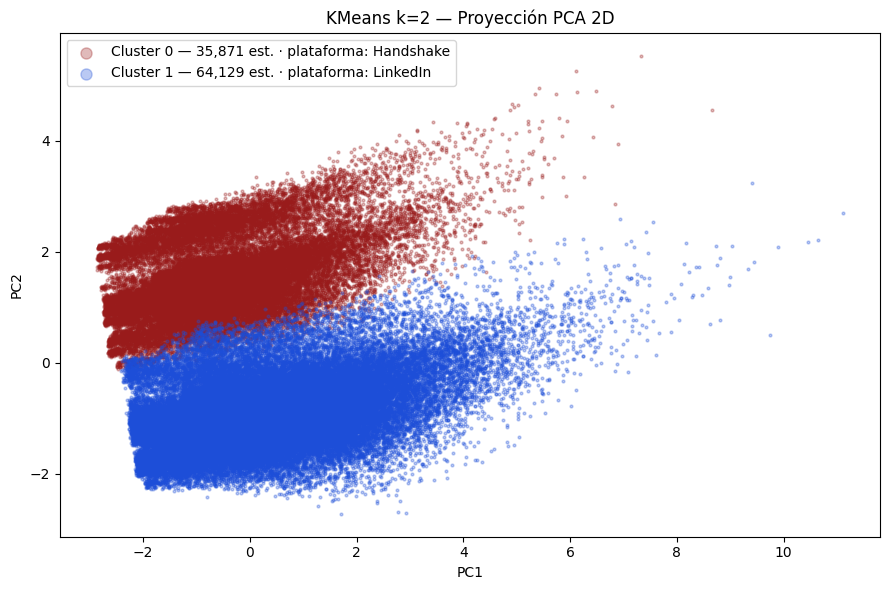

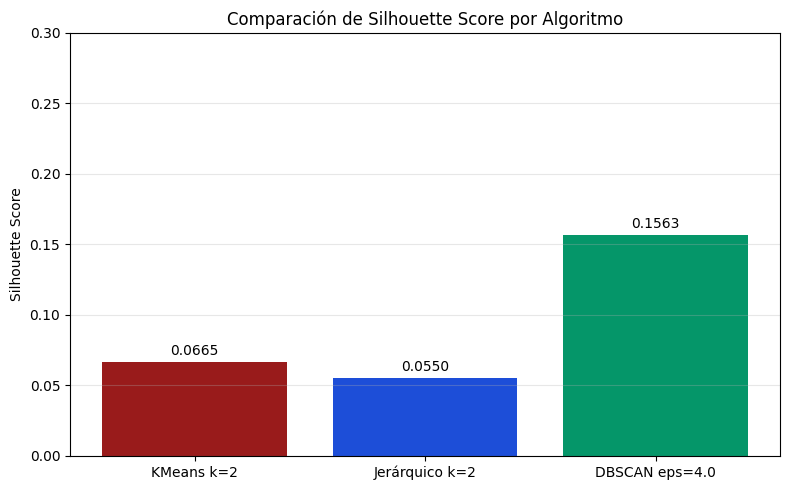

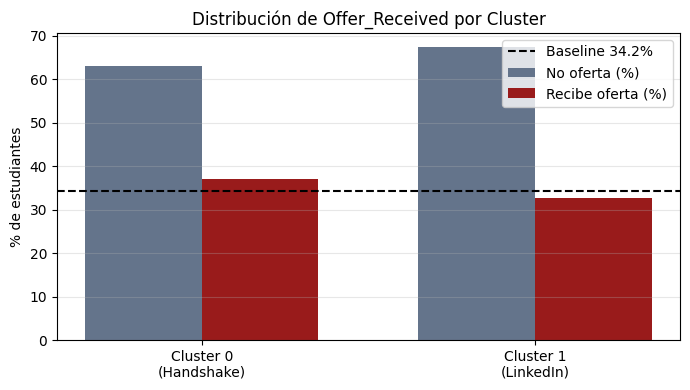

Imágenes guardadas en: /Users/apple/mineria/datalake_gold/outputs_clustering/imagenes


In [20]:
# === Exportación de imágenes de clustering ===
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def resolve_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "datalake_silver").exists() and (candidate / "datalake_gold").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del proyecto.")

ROOT_C = resolve_root()
CLUST_OUTPUT = ROOT_C / "datalake_gold" / "outputs_clustering"
IMG_DIR_C = CLUST_OUTPUT / "imagenes"
INF_DIR_C = CLUST_OUTPUT / "informe"
IMG_DIR_C.mkdir(parents=True, exist_ok=True)
INF_DIR_C.mkdir(parents=True, exist_ok=True)

# -- Scatter KMeans --
COLORS_C = ["#991b1b", "#1d4ed8"]
fig, ax = plt.subplots(figsize=(9, 6))
for i in range(K_OPTIMO):
    mask = km_labels == i
    label = f"Cluster {i} — {mask.sum():,} est. · plataforma: {cluster_profiles[i]['plataforma_dominante']}"
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=COLORS_C[i], alpha=0.3, s=4, label=label)
ax.set_title("KMeans k=2 — Proyección PCA 2D")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(markerscale=4)
plt.tight_layout()
fig.savefig(IMG_DIR_C / "clustering_kmeans_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

# -- Silhouette comparison --
sil_labels_c = ["KMeans k=2", "Jerárquico k=2", f"DBSCAN eps={EPS_INICIAL}"]
sil_vals_c = [
    float(sil_km)   if not np.isnan(float(sil_km))   else 0.0,
    float(sil_hier) if not np.isnan(float(sil_hier)) else 0.0,
    float(sil_db)   if (sil_db == sil_db)            else 0.0,
]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sil_labels_c, sil_vals_c, color=["#991b1b", "#1d4ed8", "#059669"])
ax.set_ylabel("Silhouette Score")
ax.set_title("Comparación de Silhouette Score por Algoritmo")
ax.set_ylim(0, 0.3)
for bar, val in zip(bars, sil_vals_c):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f"{val:.4f}", ha="center", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR_C / "clustering_silhouette_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

# -- Offer rate by cluster --
fig, ax = plt.subplots(figsize=(7, 4))
x_pos = np.arange(K_OPTIMO)
w = 0.35
no_oferta_pct = [
    (km_labels == i).sum() and (y_real[km_labels == i] == 0).sum() / (km_labels == i).sum() * 100
    for i in range(K_OPTIMO)
]
si_oferta_pct = [cluster_profiles[i]["offer_rate"] * 100 for i in range(K_OPTIMO)]
ax.bar(x_pos - w / 2, no_oferta_pct, w, label="No oferta (%)", color="#64748b")
ax.bar(x_pos + w / 2, si_oferta_pct, w, label="Recibe oferta (%)", color="#991b1b")
ax.axhline(y_real.mean() * 100, color="black", linestyle="--",
           label=f"Baseline {y_real.mean()*100:.1f}%")
ax.set_xticks(x_pos)
ax.set_xticklabels([
    f"Cluster {i}\n({cluster_profiles[i]['plataforma_dominante']})" for i in range(K_OPTIMO)
])
ax.set_ylabel("% de estudiantes")
ax.set_title("Distribución de Offer_Received por Cluster")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR_C / "clustering_offer_rate_by_cluster.png", dpi=160, bbox_inches="tight")
plt.show()

print("Imágenes guardadas en:", IMG_DIR_C)

In [21]:
# === JSON summary y PKL en ruta estándar ===
import pickle, json
import pandas as pd

SUMMARY_PATH_C = INF_DIR_C / "clustering_summary.json"
PKL_STD_PATH = INF_DIR_C / "clustering_kmeans.pkl"

def make_jsonable_c(value):
    if isinstance(value, Path): return str(value)
    if isinstance(value, pd.DataFrame): return json.loads(value.to_json(orient="records", force_ascii=False))
    if isinstance(value, pd.Series):    return json.loads(value.to_json(force_ascii=False))
    if isinstance(value, dict):   return {str(k): make_jsonable_c(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)): return [make_jsonable_c(i) for i in value]
    if isinstance(value, np.generic): return value.item()
    if isinstance(value, np.ndarray): return value.tolist()
    return value

# Perfiles por cluster para el JSON
crosstab_data = []
for cluster_id in range(K_OPTIMO):
    mask = km_labels == cluster_id
    crosstab_data.append({
        "cluster": int(cluster_id),
        "n_estudiantes": int(mask.sum()),
        "no_oferta": int((y_real[mask] == 0).sum()),
        "si_oferta": int((y_real[mask] == 1).sum()),
        "offer_rate_pct": round(float(y_real[mask].mean() * 100), 2),
        "plataforma_dominante": str(cluster_profiles[cluster_id]["plataforma_dominante"]),
        "aplicaciones_promedio": round(float(cluster_profiles[cluster_id]["aplicaciones_promedio"]), 1),
        "meses_busqueda_promedio": round(float(cluster_profiles[cluster_id]["meses_busqueda_promedio"]), 1),
        "entrevistas_primera_ronda": round(float(cluster_profiles[cluster_id]["entrevistas_primera_ronda"]), 2),
    })

summary_c = {
    "dataset_size": int(len(y_real)),
    "baseline_offer_rate_pct": round(float(y_real.mean() * 100), 2),
    "algorithms": {
        "kmeans": {
            "k": K_OPTIMO,
            "silhouette": round(float(sil_km), 4),
            "dunn": round(float(dunn_km), 4),
            "cluster_profiles": crosstab_data,
        },
        "jerarquico": {
            "k": 2,
            "silhouette": round(float(sil_hier), 4) if not np.isnan(float(sil_hier)) else None,
            "dunn": round(float(dunn_hier), 4) if not np.isnan(float(dunn_hier)) else None,
            "sample_size": HIER_SAMPLE,
        },
        "dbscan": {
            "eps": EPS_INICIAL,
            "min_samples": MIN_SAMPLES,
            "n_clusters": n_clusters_db,
            "n_ruido": n_ruido_db,
            "silhouette": round(float(sil_db), 4) if (sil_db == sil_db) else None,
        },
    },
    "conclusion": "No se encontraron clusters naturales alineados con empleabilidad. KMeans separó por plataforma de búsqueda (Handshake vs LinkedIn/Indeed), no por resultado laboral.",
    "images": {
        "kmeans_scatter": str(IMG_DIR_C / "clustering_kmeans_scatter.png"),
        "silhouette_comparison": str(IMG_DIR_C / "clustering_silhouette_comparison.png"),
        "offer_rate_by_cluster": str(IMG_DIR_C / "clustering_offer_rate_by_cluster.png"),
    },
}

with open(SUMMARY_PATH_C, "w", encoding="utf-8") as f:
    json.dump(make_jsonable_c(summary_c), f, indent=2, ensure_ascii=False)

# PKL en ruta estándar (además del original en raíz del proyecto)
artefacto_std = {
    "modelo": km_model,
    "scaler": scaler,
    "feature_columns_originales": FEATURE_COLS,
    "feature_names_encoded": X_encoded.columns.tolist(),
    "numeric_cols": NUM_COLS,
    "categorical_cols": CAT_COLS,
    "k_optimo": K_OPTIMO,
    "silhouette_score": float(sil_km),
    "cluster_profiles": cluster_profiles,
}
with open(PKL_STD_PATH, "wb") as f:
    pickle.dump(artefacto_std, f)

print(f"Summary JSON guardado: {SUMMARY_PATH_C}")
print(f"PKL estándar guardado: {PKL_STD_PATH}")
print("✓ Exportación de clustering completa.")

Summary JSON guardado: /Users/apple/mineria/datalake_gold/outputs_clustering/informe/clustering_summary.json
PKL estándar guardado: /Users/apple/mineria/datalake_gold/outputs_clustering/informe/clustering_kmeans.pkl
✓ Exportación de clustering completa.
